In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\AI_Course\ModularProgramProjects\finalProject\data\raw_data\cleaned_raw_data.csv")

sns.set_theme(style="whitegrid", palette="muted")

# Narx va Masofa (Range) o'rtasidagi bog'liqlik

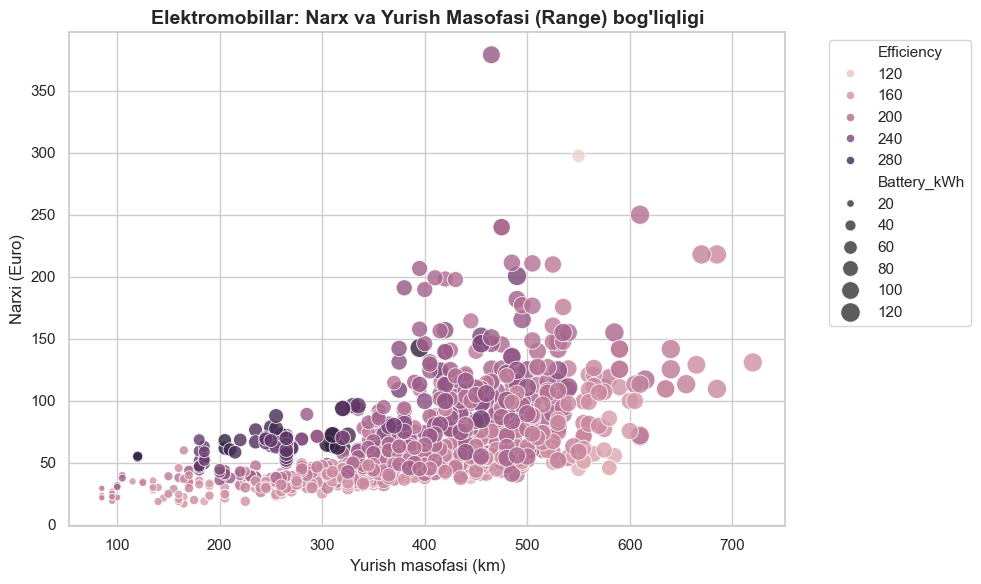

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Range_km', 
    y='Price_Euro', 
    size='Battery_kWh', # Batareya hajmi nuqta kattaligida
    hue='Efficiency',   # Samaradorlik ranglarda
    sizes=(20, 200), 
    alpha=0.8
)
plt.title("Elektromobillar: Narx va Yurish Masofasi (Range) bog'liqligi", fontsize=14, fontweight='bold')
plt.xlabel("Yurish masofasi (km)")
plt.ylabel("Narxi (Euro)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legendni chetga surish
plt.tight_layout()
plt.show()

# Correlation Heatmap

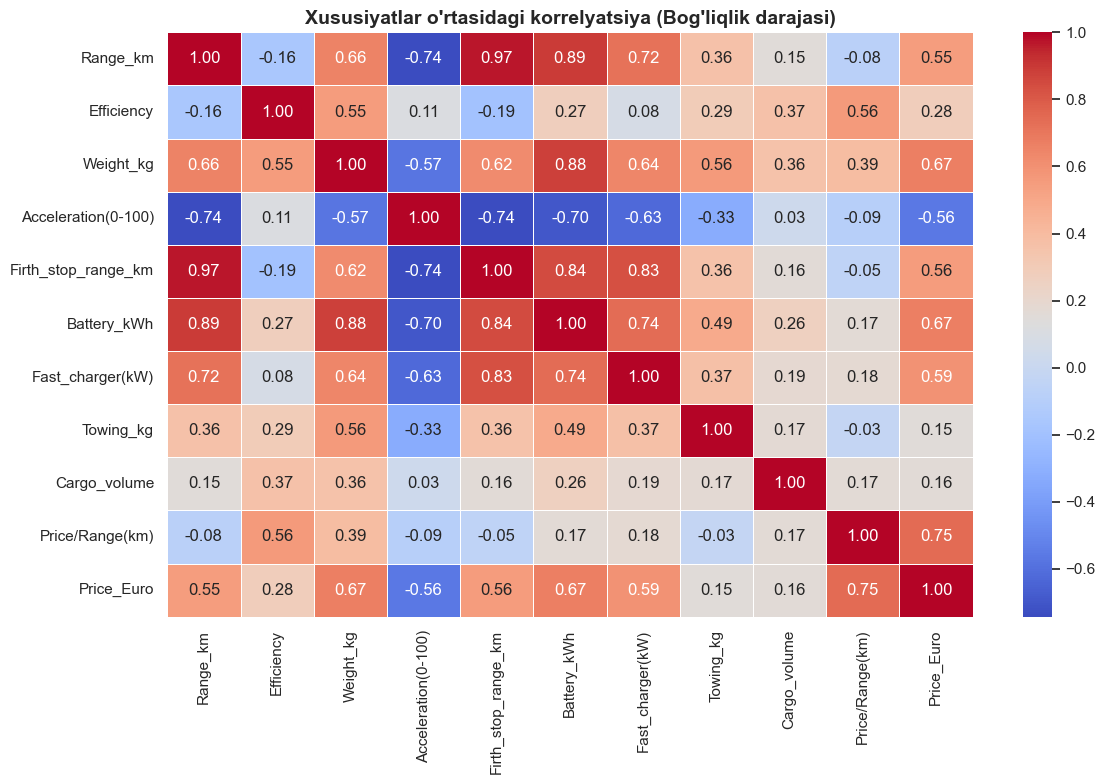

In [5]:
plt.figure(figsize=(12, 8))
# Faqat raqamli ustunlarni ajratib olamiz (Name ustuni xalaqit bermasligi uchun)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Korrelyatsiya matritsasini hisoblash
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Xususiyatlar o'rtasidagi korrelyatsiya (Bog'liqlik darajasi)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Eng uzoq masofaga yuradigan Top-10

C:\Users\bunyo\AppData\Local\Temp\ipykernel_14836\1579470783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_range, x='Range_km', y='Name', palette='viridis')


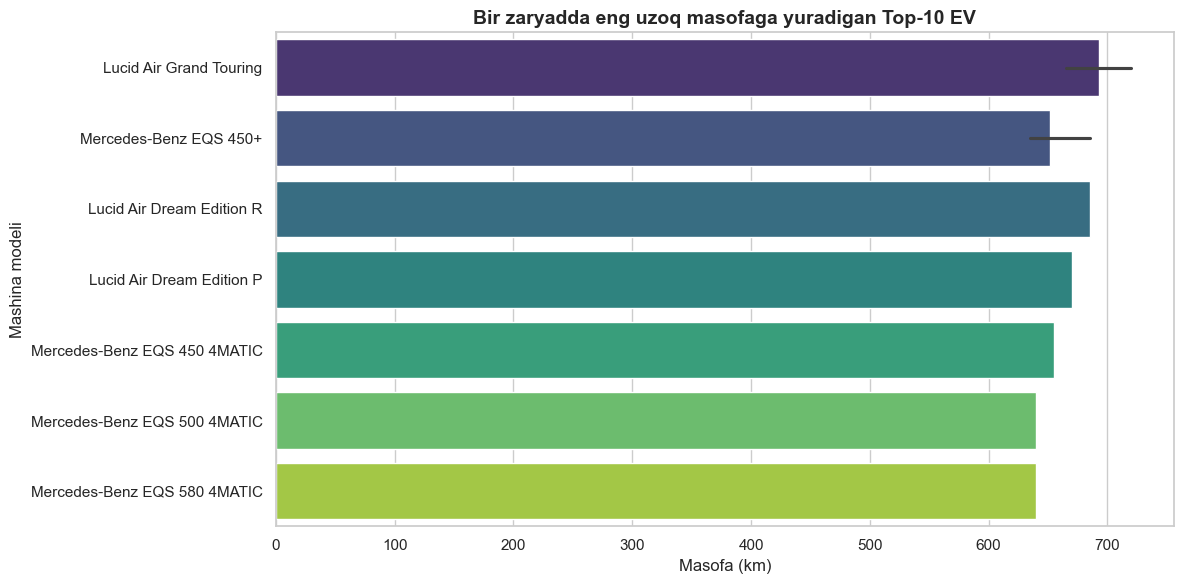

In [6]:
# Range bo'yicha eng yuqori 10 ta mashinani ajratib olamiz
top_10_range = df.nlargest(10, 'Range_km')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_range, x='Range_km', y='Name', palette='viridis')
plt.title("Bir zaryadda eng uzoq masofaga yuradigan Top-10 EV", fontsize=14, fontweight='bold')
plt.xlabel("Masofa (km)")
plt.ylabel("Mashina modeli")
plt.tight_layout()
plt.show()

# Tezlanish (0-100) va Og'irlik o'rtasidagi ziddiyat

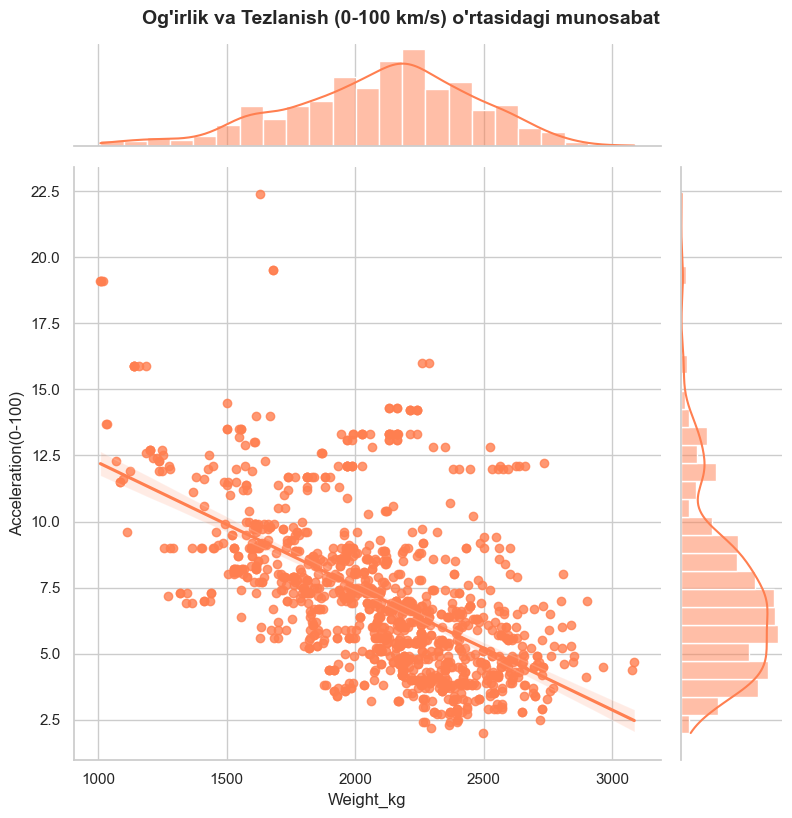

In [7]:
sns.jointplot(
    data=df, 
    x='Weight_kg', 
    y='Acceleration(0-100)', 
    kind="reg", # Regressiya chizig'i
    color="coral",
    height=8
)
plt.suptitle("Og'irlik va Tezlanish (0-100 km/s) o'rtasidagi munosabat", y=1.02, fontsize=14, fontweight='bold')
plt.show()